GENRE AND OVERVIEW ANALYSIS

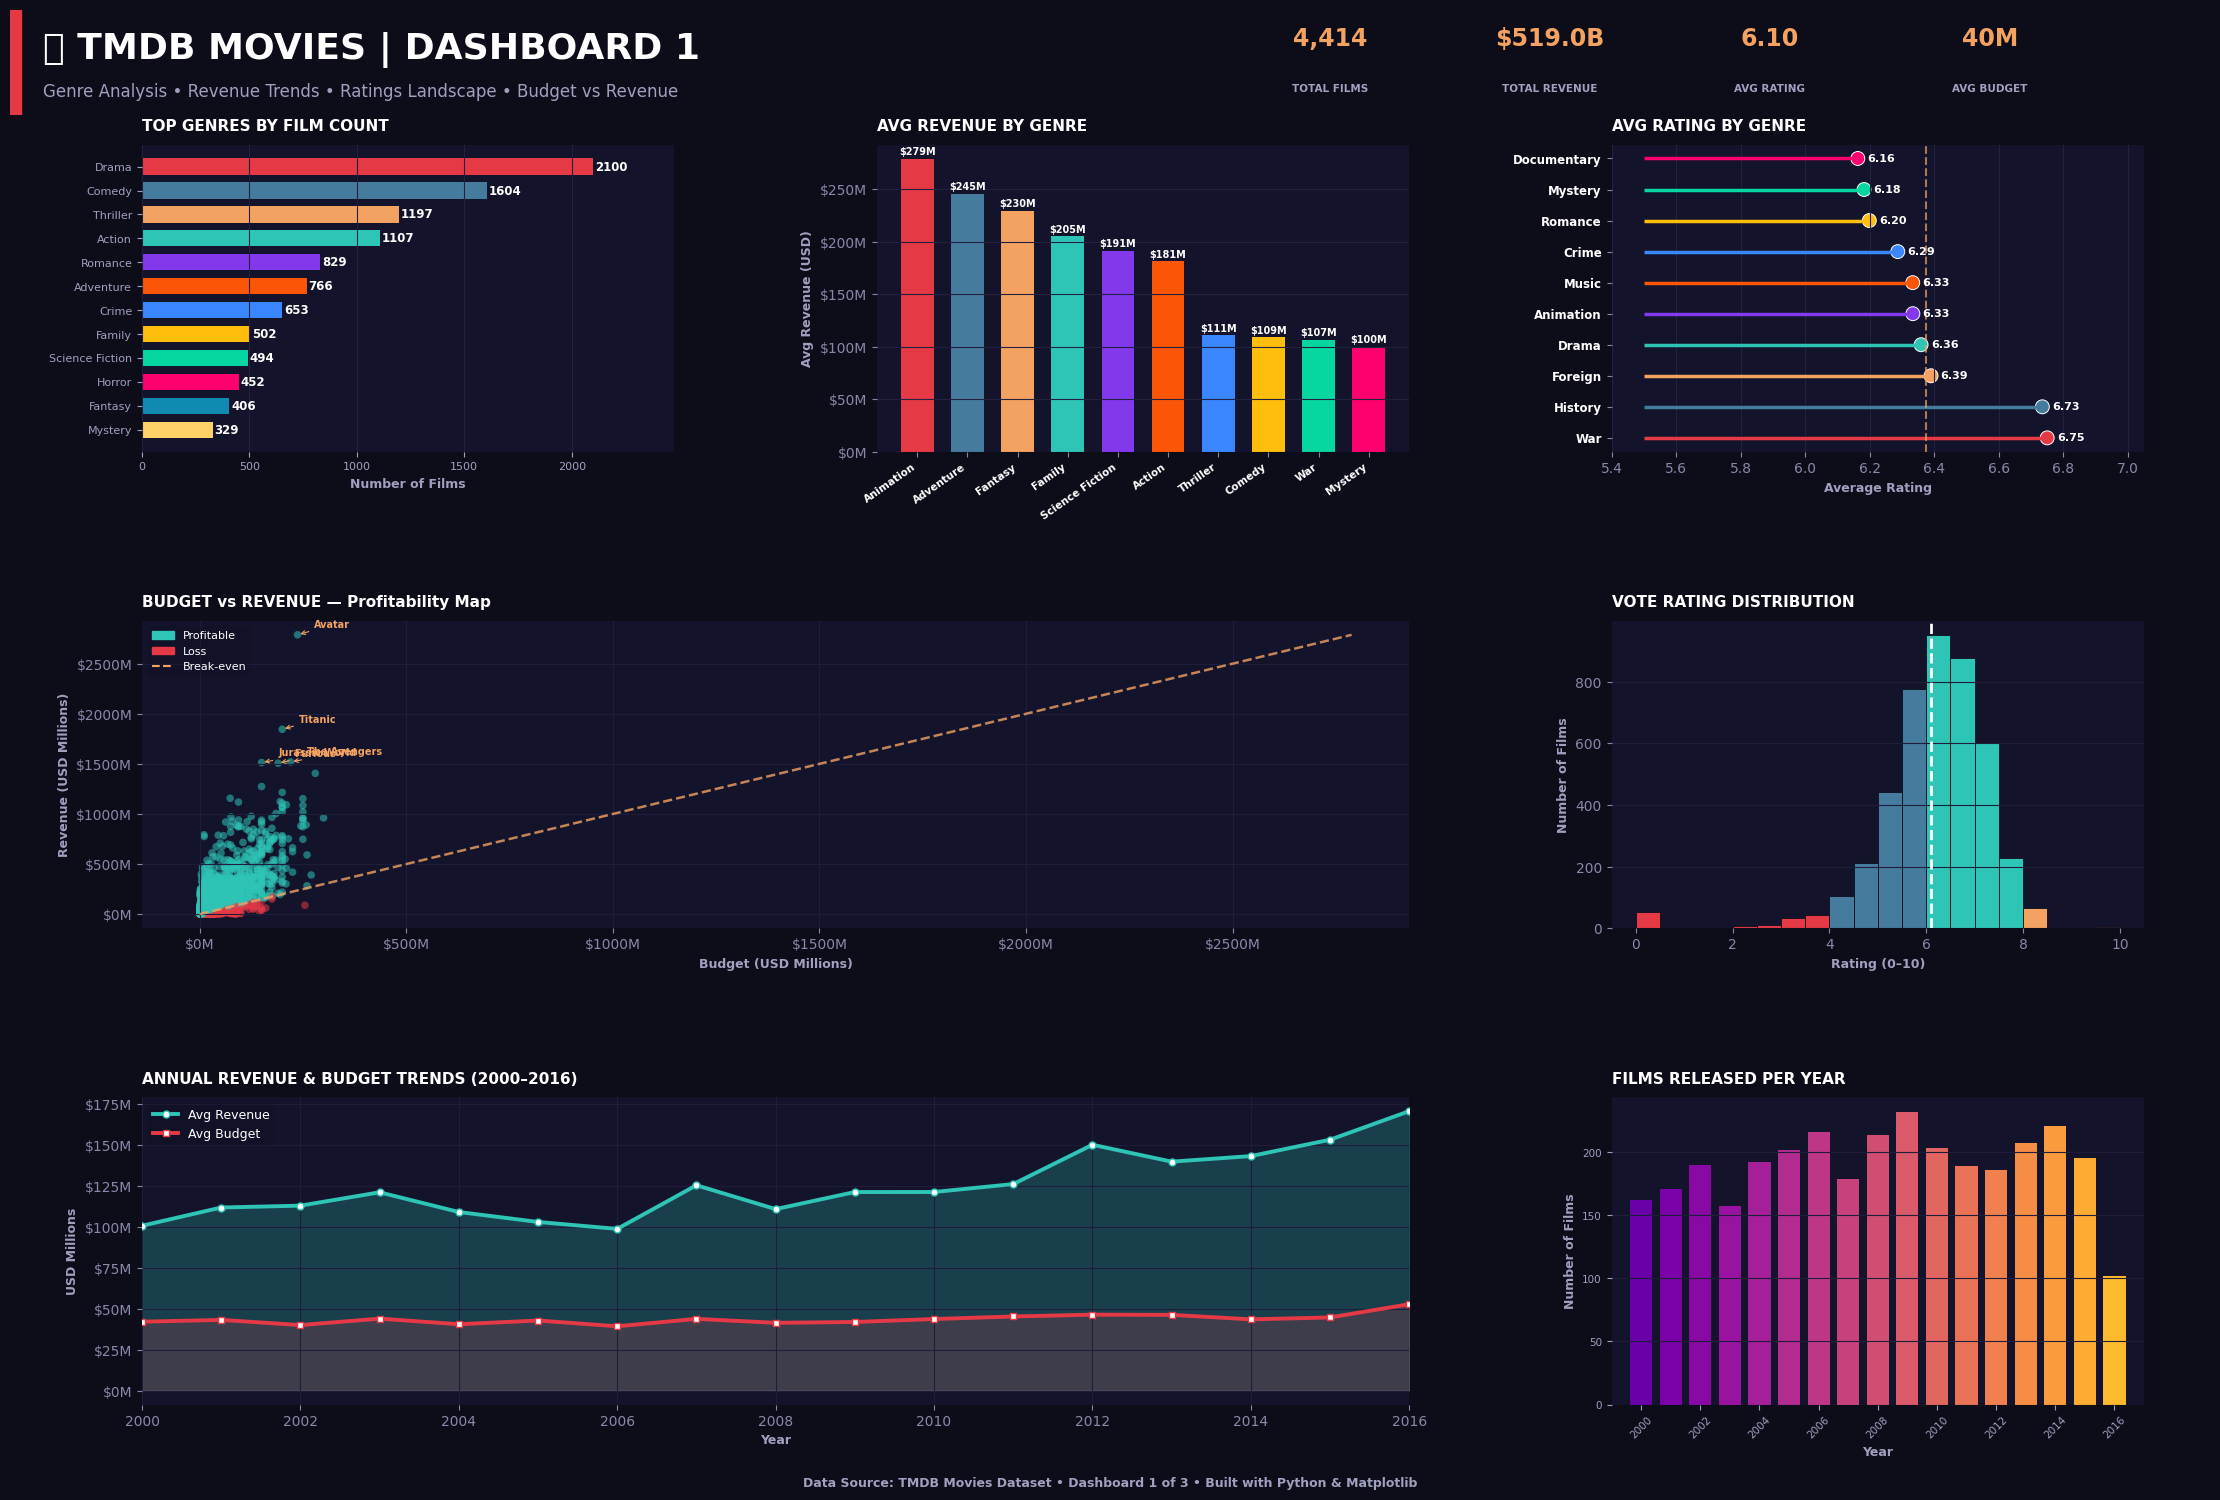

In [42]:
# ── IMPORTS ──────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np

# %% [markdown]
# ## 1️⃣ Load & Prepare Data

# %%
# Load dataset
df = pd.read_csv('tmdb_movies_dataset.csv')

# Extract release year
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Filter out movies with very low budget/revenue
df = df[(df['budget'] > 1_000_000) & (df['revenue'] > 1_000_000)]

# Compute profit & ROI
df['profit'] = df['revenue'] - df['budget']
df['roi'] = (df['profit'] / df['budget']) * 100

# %% [markdown]
# ## 2️⃣ Genre Data Explosion

# %%
# Explode genres into separate rows
genre_rows = []
for _, row in df.iterrows():
    if pd.notna(row['genres']):
        for g in str(row['genres']).split(' | '):
            genre_rows.append({
                'genre': g.strip(),
                'revenue': row['revenue'],
                'vote_average': row['vote_average'],
                'budget': row['budget']
            })
gdf = pd.DataFrame(genre_rows)

# Metrics per genre
genre_counts = gdf['genre'].value_counts().head(12)
genre_revenue = gdf.groupby('genre')['revenue'].mean().sort_values(ascending=False).head(12)
genre_rating = gdf.groupby('genre')['vote_average'].mean().sort_values(ascending=False).head(12)

# Year trends (2000–2016)
year_df = df[df['year'].between(2000, 2016)]
yr_rev = year_df.groupby('year')['revenue'].mean() / 1e6
yr_budget = year_df.groupby('year')['budget'].mean() / 1e6
yr_count = year_df.groupby('year').size()

# %% [markdown]
# ## 3️⃣ Color Palette & Helper Functions

# %%
BG       = '#0D0D1A'
CARD     = '#13132B'
ACCENT1  = '#E63946'  # red
ACCENT2  = '#457B9D'  # blue
ACCENT3  = '#F4A261'  # amber
ACCENT4  = '#2EC4B6'  # teal
WHITE    = '#FFFFFF'
LGRAY    = '#A0A0C0'

GENRE_COLORS = [
    '#E63946','#457B9D','#F4A261','#2EC4B6','#8338EC',
    '#FB5607','#3A86FF','#FFBE0B','#06D6A0','#FF006E',
    '#118AB2','#FFD166'
]

# Money formatter
def millions(x, pos): return f'${x/1e6:.0f}M'

# %% [markdown]
# ## 4️⃣ Dashboard Visualization

# %%
# Figure setup
fig = plt.figure(figsize=(22, 15), facecolor=BG)
gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.55, wspace=0.38,
                       left=0.06, right=0.97, top=0.91, bottom=0.07)

# ── Title & Summary Stats ──
ax_title = fig.add_axes([0, 0.93, 1, 0.07], facecolor=CARD)
ax_title.axis('off')
ax_title.add_patch(plt.Rectangle((0,0), 0.005, 1, color=ACCENT1, transform=ax_title.transAxes))
ax_title.text(0.015, 0.62, '🎬 TMDB MOVIES | DASHBOARD 1', transform=ax_title.transAxes,
              fontsize=26, fontweight='black', color=WHITE, va='center')
ax_title.text(0.015, 0.22, 'Genre Analysis • Revenue Trends • Ratings Landscape • Budget vs Revenue',
              transform=ax_title.transAxes, fontsize=12, color=LGRAY, va='center')

# Summary stats
total_movies = len(df)
total_revenue = df['revenue'].sum() / 1e9
avg_rating = df['vote_average'].mean()
avg_budget = df['budget'].mean() / 1e6
stats = [(f'{total_movies:,}', 'TOTAL FILMS'),
         (f'${total_revenue:.1f}B', 'TOTAL REVENUE'),
         (f'{avg_rating:.2f}', 'AVG RATING'),
         (f'{avg_budget:.0f}M', 'AVG BUDGET')]

for i, (val, label) in enumerate(stats):
    x = 0.60 + i * 0.10
    ax_title.text(x, 0.66, val, transform=ax_title.transAxes,
                  fontsize=17, fontweight='black', color=ACCENT3, ha='center')
    ax_title.text(x, 0.22, label, transform=ax_title.transAxes,
                  fontsize=7.5, color=LGRAY, ha='center', fontweight='bold')

# ── Chart 1: Top Genres by Film Count ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(CARD)
bars = ax1.barh(genre_counts.index[::-1], genre_counts.values[::-1],
                color=GENRE_COLORS[:len(genre_counts)][::-1], height=0.68)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax1.text(val + 8, bar.get_y() + bar.get_height()/2, f'{val}', va='center',
             fontsize=8.5, fontweight='bold', color=WHITE)
ax1.set_title('TOP GENRES BY FILM COUNT', fontsize=11, fontweight='black', color=WHITE, pad=10, loc='left')
ax1.set_xlabel('Number of Films', fontsize=9, color=LGRAY, fontweight='bold')
ax1.set_xlim(0, genre_counts.max() * 1.18)
ax1.xaxis.grid(True, color='#222240', linewidth=0.8)
ax1.tick_params(colors=LGRAY, labelsize=8)
for spine in ax1.spines.values(): spine.set_visible(False)

# ── Chart 2: Avg Revenue by Genre ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD)
top_genres = genre_revenue.head(10)
x = np.arange(len(top_genres))
bars2 = ax2.bar(x, top_genres.values / 1e6, color=GENRE_COLORS[:len(top_genres)], width=0.65)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f'${bar.get_height():.0f}M', ha='center', fontsize=7, fontweight='bold', color=WHITE)
ax2.set_xticks(x)
ax2.set_xticklabels(top_genres.index, rotation=35, ha='right', fontsize=7.5, color=WHITE, fontweight='bold')
ax2.set_title('AVG REVENUE BY GENRE', fontsize=11, fontweight='black', color=WHITE, pad=10, loc='left')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M'))
ax2.set_ylabel('Avg Revenue (USD)', fontsize=9, color=LGRAY, fontweight='bold')
ax2.yaxis.grid(True, color='#222240', linewidth=0.8)
for spine in ax2.spines.values(): spine.set_visible(False)

# ── Chart 3: Avg Rating by Genre ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(CARD)
top_r = genre_rating.head(10)
x3 = np.arange(len(top_r))
ax3.hlines(x3, 5.5, top_r.values, color=GENRE_COLORS[:len(top_r)], linewidth=2.5)
ax3.scatter(top_r.values, x3, color=GENRE_COLORS[:len(top_r)], s=100, edgecolors=WHITE, linewidths=0.7)
ax3.axvline(top_r.mean(), color=ACCENT3, linestyle='--', linewidth=1.5, alpha=0.7)
for val, y in zip(top_r.values, x3):
    ax3.text(val + 0.03, y, f'{val:.2f}', va='center', fontsize=8, fontweight='bold', color=WHITE)
ax3.set_yticks(x3)
ax3.set_yticklabels(top_r.index, fontsize=8.5, color=WHITE, fontweight='bold')
ax3.set_title('AVG RATING BY GENRE', fontsize=11, fontweight='black', color=WHITE, pad=10, loc='left')
ax3.set_xlabel('Average Rating', fontsize=9, color=LGRAY, fontweight='bold')
ax3.set_xlim(5.4, top_r.max() + 0.3)
ax3.xaxis.grid(True, color='#222240', linewidth=0.8)
for spine in ax3.spines.values(): spine.set_visible(False)

# ── Chart 4: Budget vs Revenue Scatter ──
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor(CARD)
scatter_df = df[(df['budget'] < 3.5e8) & (df['revenue'] < 2.9e9)].copy()
sc = ax4.scatter(scatter_df['budget']/1e6, scatter_df['revenue']/1e6,
                 c=np.where(scatter_df['profit']>0, ACCENT4, ACCENT1),
                 alpha=0.55, s=30, edgecolors='none')
max_val = max(scatter_df['budget'].max(), scatter_df['revenue'].max()) / 1e6
ax4.plot([0, max_val], [0, max_val], '--', color=ACCENT3, linewidth=1.8, alpha=0.8)
top5 = df.nlargest(5, 'revenue')
for _, row in top5.iterrows():
    ax4.annotate(row['title'][:18], xy=(row['budget']/1e6, row['revenue']/1e6),
                 xytext=(12, 5), textcoords='offset points',
                 fontsize=7, color=ACCENT3, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=ACCENT3, lw=0.8))
legend_elems = [mpatches.Patch(color=ACCENT4, label='Profitable'),
                mpatches.Patch(color=ACCENT1, label='Loss'),
                plt.Line2D([0],[0], color=ACCENT3, linestyle='--', label='Break-even')]
ax4.legend(handles=legend_elems, fontsize=8, framealpha=0.2,
           facecolor=BG, edgecolor='none', labelcolor=WHITE)
ax4.set_title('BUDGET vs REVENUE — Profitability Map', fontsize=11,
              fontweight='black', color=WHITE, pad=10, loc='left')
ax4.set_xlabel('Budget (USD Millions)', fontsize=9, color=LGRAY, fontweight='bold')
ax4.set_ylabel('Revenue (USD Millions)', fontsize=9, color=LGRAY, fontweight='bold')
ax4.xaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M'))
ax4.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M'))
ax4.grid(True, color='#1E1E3A', linewidth=0.8)
for spine in ax4.spines.values(): spine.set_visible(False)

# ── Chart 5: Vote Distribution ──
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(CARD)
bins = np.arange(0, 10.5, 0.5)
n, edges, patches_list = ax5.hist(df['vote_average'], bins=bins, color=ACCENT2,
                                   edgecolor=BG, linewidth=0.6)
for patch, left in zip(patches_list, edges):
    if left < 4: patch.set_facecolor(ACCENT1)
    elif left < 6: patch.set_facecolor(ACCENT2)
    elif left < 8: patch.set_facecolor(ACCENT4)
    else: patch.set_facecolor(ACCENT3)
ax5.axvline(df['vote_average'].mean(), color=WHITE, linewidth=2, linestyle='--')
ax5.set_title('VOTE RATING DISTRIBUTION', fontsize=11, fontweight='black', color=WHITE, pad=10, loc='left')
ax5.set_xlabel('Rating (0–10)', fontsize=9, color=LGRAY, fontweight='bold')
ax5.set_ylabel('Number of Films', fontsize=9, color=LGRAY, fontweight='bold')
ax5.yaxis.grid(True, color='#1E1E3A', linewidth=0.8)
for spine in ax5.spines.values(): spine.set_visible(False)

# ── Chart 6: Annual Revenue & Budget Trends ──
ax6 = fig.add_subplot(gs[2, 0:2])
ax6.set_facecolor(CARD)
ax6.fill_between(yr_rev.index, yr_rev.values, alpha=0.25, color=ACCENT4)
ax6.plot(yr_rev.index, yr_rev.values, color=ACCENT4, linewidth=2.8, marker='o',
         markersize=5, markerfacecolor=WHITE, markeredgecolor=ACCENT4, label='Avg Revenue')
ax6.fill_between(yr_budget.index, yr_budget.values, alpha=0.18, color=ACCENT1)
ax6.plot(yr_budget.index, yr_budget.values, color=ACCENT1, linewidth=2.8, marker='s',
         markersize=5, markerfacecolor=WHITE, markeredgecolor=ACCENT1, label='Avg Budget')
ax6.set_title('ANNUAL REVENUE & BUDGET TRENDS (2000–2016)', fontsize=11,
              fontweight='black', color=WHITE, pad=10, loc='left')
ax6.set_xlabel('Year', fontsize=9, color=LGRAY, fontweight='bold')
ax6.set_ylabel('USD Millions', fontsize=9, color=LGRAY, fontweight='bold')
ax6.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M'))
ax6.legend(fontsize=9, framealpha=0.2, facecolor=BG, edgecolor='none', labelcolor=WHITE)
ax6.grid(True, color='#1E1E3A', linewidth=0.8)
for spine in ax6.spines.values(): spine.set_visible(False)
ax6.set_xlim(2000, 2016)

# ── Chart 7: Films Released Per Year ──
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(CARD)
colors7 = plt.cm.plasma(np.linspace(0.2, 0.85, len(yr_count)))
ax7.bar(yr_count.index, yr_count.values, color=colors7, edgecolor='none', width=0.75)
ax7.set_title('FILMS RELEASED PER YEAR', fontsize=11, fontweight='black', color=WHITE, pad=10, loc='left')
ax7.set_xlabel('Year', fontsize=9, color=LGRAY, fontweight='bold')
ax7.set_ylabel('Number of Films', fontsize=9, color=LGRAY, fontweight='bold')
ax7.tick_params(colors=LGRAY, labelsize=7.5)
ax7.xaxis.set_tick_params(rotation=45)
ax7.yaxis.grid(True, color='#1E1E3A', linewidth=0.8)
for spine in ax7.spines.values(): spine.set_visible(False)
ax7.set_xlim(1999, 2017)

# ── Footer ──
fig.text(0.5, 0.015, 'Data Source: TMDB Movies Dataset • Dashboard 1 of 3 • Built with Python & Matplotlib',
         ha='center', fontsize=9, color=LGRAY, fontweight='bold')

# ── Show Figure ──
plt.show()


FINANCIAL AND ROI ANALYSIS

✅ Dataset loaded: 4414 movies after cleaning
✅ All data prepared successfully


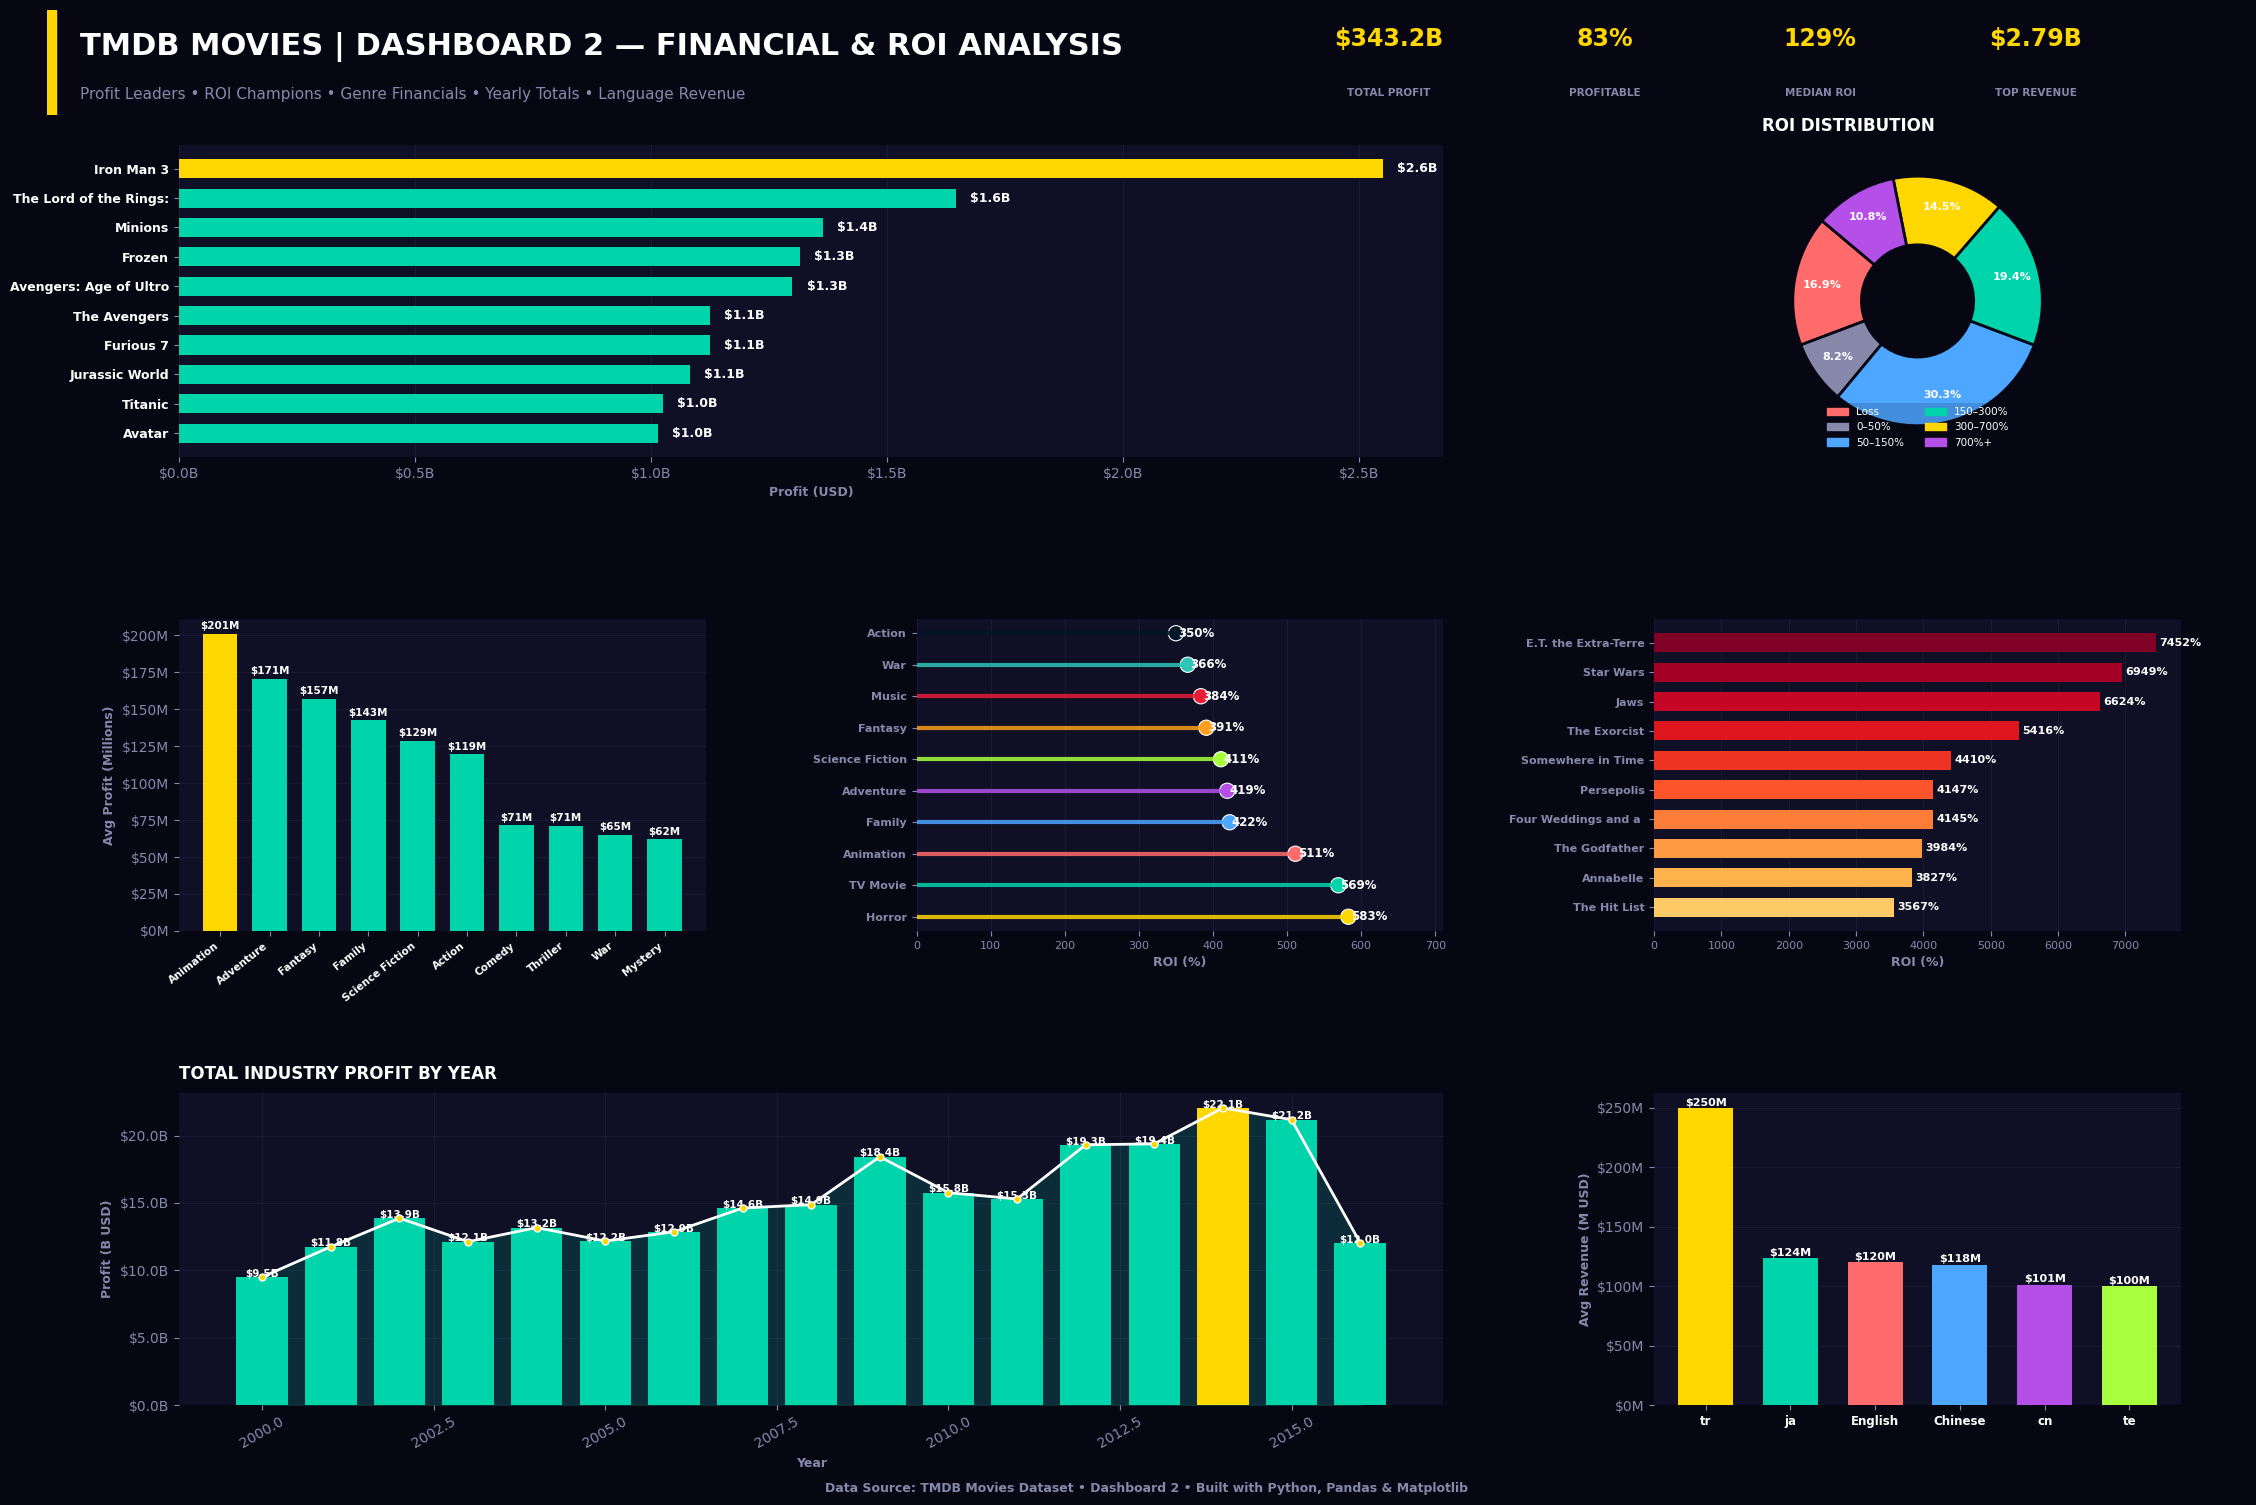

In [ ]:

# TMDB Movies Dashboard 2: Financial & ROI Analysis
# Works perfectly in Jupyter Notebook


# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')  # ignore minor warnings


# STEP 1: Load & Clean the Data


df = pd.read_csv('tmdb_movies_dataset.csv')

# Extract release year
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Keep only movies with meaningful budget & revenue
df = df[(df['budget'] > 1_000_000) & (df['revenue'] > 1_000_000)].copy()

# Compute profit and ROI
df['profit'] = df['revenue'] - df['budget']
df['roi']    = (df['profit'] / df['budget']) * 100

print(f"✅ Dataset loaded: {len(df)} movies after cleaning")


# STEP 2: Prepare Data for Charts


# Create genre-level rows (one row per genre per movie)
genre_rows = []
for _, row in df.iterrows():
    if pd.notna(row['genres']):
        for g in str(row['genres']).split(' | '):
            genre_rows.append({
                'genre': g.strip(),
                'revenue': row['revenue'],
                'budget': row['budget'],
                'profit': row['profit'],
                'roi': row['roi'],
                'vote_average': row['vote_average'],
                'popularity': row['popularity']
            })
gdf = pd.DataFrame(genre_rows)

# Top 10 profitable movies
top_profit = df.nlargest(10, 'profit')[['title','profit','budget','revenue']].reset_index(drop=True)

# Top 10 ROI movies (budget > $5M to avoid outliers)
top_roi = df[df['budget']>5_000_000].nlargest(10, 'roi')[['title','roi','budget','revenue']].reset_index(drop=True)

# Average profit & ROI per genre
genre_profit = gdf.groupby('genre')['profit'].mean().sort_values(ascending=False).head(10)
genre_roi    = gdf.groupby('genre')['roi'].mean().sort_values(ascending=False).head(10)

# Total industry profit per year (2000-2016)
yr_df     = df[df['year'].between(2000, 2016)]
yr_profit = yr_df.groupby('year')['profit'].sum() / 1e9  # in billions

# ROI distribution buckets
df['roi_bucket'] = pd.cut(
    df['roi'],
    bins=[-200,0,50,150,300,700,5000],
    labels=['Loss','0–50%','50–150%','150–300%','300–700%','700%+']
)
roi_dist = df['roi_bucket'].value_counts()

# Top 6 languages by average revenue
lang_rev = df.groupby('original_language')['revenue'].mean().sort_values(ascending=False).head(6)

print("✅ All data prepared successfully")


# STEP 3: Define Colors & Styling


# Backgrounds, text, and highlight colors
BG     = '#070714'
CARD   = '#0F0F26'
GOLD   = '#FFD700'
TEAL   = '#00D4AA'
CORAL  = '#FF6B6B'
BLUE   = '#4DA6FF'
PURPLE = '#B44FE8'
LIME   = '#A8FF3E'
WHITE  = '#FFFFFF'
LGRAY  = '#8888AA'

# Multi-color palette for charts
PALETTE = [GOLD, TEAL, CORAL, BLUE, PURPLE, LIME, '#FF9F1C', '#E71D36', '#2EC4B6', '#011627']

# Global style settings
plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : CARD,
    'text.color'       : WHITE,
    'xtick.color'      : LGRAY,
    'ytick.color'      : LGRAY,
    'font.family'      : 'DejaVu Sans',
    'grid.color'       : '#1A1A35',
    'grid.linewidth'   : 0.8
})

# STEP 4: Create Dashboard Figure


fig = plt.figure(figsize=(22, 15), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.40,
                        left=0.06, right=0.97, top=0.91, bottom=0.07)

# ------------------ Title Banner --------------------------
ax_t = fig.add_axes([0, 0.93, 1, 0.07], facecolor=CARD)
ax_t.set_xlim(0, 1); ax_t.set_ylim(0, 1); ax_t.axis('off')
ax_t.add_patch(plt.Rectangle((0, 0), 0.004, 1, color=GOLD))
ax_t.text(0.015, 0.65, 'TMDB MOVIES | DASHBOARD 2 — FINANCIAL & ROI ANALYSIS',
          fontsize=22, fontweight='black', color=WHITE, va='center')
ax_t.text(0.015, 0.20,
          'Profit Leaders • ROI Champions • Genre Financials • Yearly Totals • Language Revenue',
          fontsize=11, color=LGRAY, va='center')

# KPI numbers
kpis = [
    (f'${df["profit"].sum()/1e9:.1f}B','TOTAL PROFIT'),
    (f'{df[df["profit"]>0].shape[0]/len(df)*100:.0f}%','PROFITABLE'),
    (f'{df["roi"].median():.0f}%','MEDIAN ROI'),
    (f'${df["revenue"].max()/1e9:.2f}B','TOP REVENUE')
]
for i, (value,label) in enumerate(kpis):
    x_pos = 0.61 + i*0.098
    ax_t.text(x_pos,0.66,value,fontsize=17,fontweight='black',color=GOLD,ha='center')
    ax_t.text(x_pos,0.18,label,fontsize=7.5,color=LGRAY,ha='center',fontweight='bold')


# STEP 5: Charts


# Chart 1: Top 10 Profitable Films (Horizontal Bar)
ax1 = fig.add_subplot(gs[0, 0:2])
profits = top_profit['profit'].values / 1e6
titles  = [t[:22] for t in top_profit['title'].values]
y_pos   = np.arange(len(titles))
bar_colors = [GOLD if i==0 else TEAL for i in range(len(titles))]
bars = ax1.barh(y_pos, profits, color=bar_colors, height=0.65, edgecolor='none')
for bar,val in zip(bars,profits):
    ax1.text(val+30, bar.get_y()+bar.get_height()/2, f'${val/1000:.1f}B', va='center', fontsize=9, fontweight='black', color=WHITE)
ax1.invert_yaxis(); ax1.set_yticks(y_pos); ax1.set_yticklabels(titles[::-1], fontsize=9, fontweight='bold', color=WHITE)
ax1.set_xlabel('Profit (USD)', fontsize=9, color=LGRAY, fontweight='bold')
ax1.xaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v/1000:.1f}B'))
ax1.xaxis.grid(True); ax1.set_axisbelow(True)
for sp in ax1.spines.values(): sp.set_visible(False)

# Chart 2: ROI Distribution Donut
ax2 = fig.add_subplot(gs[0, 2])
roi_vals = roi_dist.reindex(['Loss','0–50%','50–150%','150–300%','300–700%','700%+']).fillna(0)
pie_colors = [CORAL,LGRAY,BLUE,TEAL,GOLD,PURPLE]
wedges,texts,autotexts = ax2.pie(roi_vals.values, labels=None, colors=pie_colors,
                                 autopct=lambda p:f'{p:.1f}%' if p>3 else '', startangle=140,
                                 pctdistance=0.78, wedgeprops=dict(linewidth=2,edgecolor=BG,width=0.55))
for at in autotexts: at.set_fontsize(8); at.set_fontweight('bold'); at.set_color(WHITE)
ax2.set_title('ROI DISTRIBUTION', fontsize=12,fontweight='black',color=WHITE,pad=10,loc='left')
legend_patches = [mpatches.Patch(color=c,label=l) for c,l in zip(pie_colors,roi_vals.index)]
ax2.legend(handles=legend_patches, loc='lower center', fontsize=7.5, ncol=2, framealpha=0.15, facecolor=BG, edgecolor='none', labelcolor=WHITE)

# Chart 3: Average Profit by Genre
ax3 = fig.add_subplot(gs[1,0])
gp_vals = genre_profit.values/1e6; gp_names = genre_profit.index.tolist()
bars3 = ax3.bar(np.arange(len(gp_names)), gp_vals, color=[GOLD if v==gp_vals.max() else TEAL for v in gp_vals], edgecolor='none', width=0.7)
for bar in bars3: ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, f'${bar.get_height():.0f}M', ha='center', fontsize=7.5, fontweight='bold', color=WHITE)
ax3.set_xticks(np.arange(len(gp_names))); ax3.set_xticklabels(gp_names, rotation=38, ha='right', fontsize=7.5, fontweight='bold', color=WHITE)
ax3.set_ylabel('Avg Profit (Millions)', fontsize=9, color=LGRAY, fontweight='bold')
ax3.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M')); ax3.yaxis.grid(True); ax3.set_axisbelow(True)
for sp in ax3.spines.values(): sp.set_visible(False)

# Chart 4: Average ROI by Genre (Lollipop)
ax4 = fig.add_subplot(gs[1,1])
gr_vals = genre_roi.values; gr_names = genre_roi.index.tolist(); y4 = np.arange(len(gr_names))
ax4.hlines(y4, 0, gr_vals, color=PALETTE[:len(gr_names)], linewidth=3, alpha=0.85)
ax4.scatter(gr_vals, y4, color=PALETTE[:len(gr_names)], s=120, edgecolors=WHITE, linewidths=0.8)
for v,y in zip(gr_vals,y4): ax4.text(v+3,y,f'{v:.0f}%',va='center',fontsize=8.5,fontweight='bold',color=WHITE)
ax4.set_yticks(y4); ax4.set_yticklabels(gr_names, fontsize=8.5, fontweight='bold', color=WHITE)
ax4.set_xlabel('ROI (%)', fontsize=9, color=LGRAY, fontweight='bold'); ax4.set_xlim(0,gr_vals.max()*1.22)
ax4.xaxis.grid(True); ax4.set_axisbelow(True); ax4.tick_params(colors=LGRAY,labelsize=8)
for sp in ax4.spines.values(): sp.set_visible(False)

# Chart 5: Top 10 ROI Films
ax5 = fig.add_subplot(gs[1,2])
roi_titles = [t[:20] for t in top_roi['title'].values]; roi_pct = top_roi['roi'].values; y5 = np.arange(len(roi_titles))
bar_c5 = plt.cm.YlOrRd(np.linspace(0.3,1,len(roi_titles)))[::-1]
bars5 = ax5.barh(y5, roi_pct, color=bar_c5, height=0.65, edgecolor='none')
for bar,val in zip(bars5,roi_pct): ax5.text(val+50, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=8, fontweight='bold', color=WHITE)
ax5.set_yticks(y5); ax5.set_yticklabels(roi_titles, fontsize=8, fontweight='bold', color=WHITE)
ax5.set_xlabel('ROI (%)', fontsize=9, color=LGRAY, fontweight='bold'); ax5.invert_yaxis()
ax5.xaxis.grid(True); ax5.set_axisbelow(True); ax5.tick_params(colors=LGRAY,labelsize=8)
for sp in ax5.spines.values(): sp.set_visible(False)

# Chart 6: Total Industry Profit by Year (Bar + Line)
ax6 = fig.add_subplot(gs[2,0:2])
yrs, vals = yr_profit.index.tolist(), yr_profit.values
ax6.bar(yrs, vals, color=[GOLD if v==vals.max() else TEAL for v in vals], width=0.75, edgecolor='none', zorder=3)
ax6.plot(yrs, vals, color=WHITE, linewidth=2, marker='o', markersize=5, markerfacecolor=GOLD, markeredgecolor=WHITE, zorder=4)
ax6.fill_between(yrs, vals, alpha=0.15, color=TEAL)
for bar,v in zip(yrs, vals): ax6.text(bar, v+0.02, f'${v:.1f}B', ha='center', fontsize=7.5, fontweight='bold', color=WHITE)
ax6.set_xlabel('Year', fontsize=9, color=LGRAY, fontweight='bold'); ax6.set_ylabel('Profit (B USD)', fontsize=9, color=LGRAY, fontweight='bold')
ax6.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.1f}B')); ax6.xaxis.grid(True); ax6.yaxis.grid(True)
for sp in ax6.spines.values(): sp.set_visible(False); ax6.set_axisbelow(True); ax6.tick_params(axis='x',rotation=30); ax6.set_title('TOTAL INDUSTRY PROFIT BY YEAR', fontsize=12,fontweight='black',color=WHITE,pad=10,loc='left')

# Chart 7: Avg Revenue by Language
ax7 = fig.add_subplot(gs[2,2])
lang_labels = {'en':'English','fr':'French','es':'Spanish','zh':'Chinese','de':'German','hi':'Hindi'}
labels7 = [lang_labels.get(l,l) for l in lang_rev.index]; vals7 = lang_rev.values/1e6
colors7 = [GOLD, TEAL, CORAL, BLUE, PURPLE, LIME]
bars7 = ax7.bar(np.arange(len(labels7)), vals7, color=colors7, edgecolor='none', width=0.65, zorder=3)
for bar in bars7: ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'${bar.get_height():.0f}M', ha='center', fontsize=8, fontweight='bold', color=WHITE)
ax7.set_xticks(np.arange(len(labels7))); ax7.set_xticklabels(labels7, fontsize=8.5, fontweight='bold', color=WHITE)
ax7.set_ylabel('Avg Revenue (M USD)', fontsize=9, color=LGRAY, fontweight='bold')
ax7.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'${v:.0f}M')); ax7.yaxis.grid(True)
for sp in ax7.spines.values(): sp.set_visible(False); ax7.set_axisbelow(True)


# Footer & Display

fig.text(0.5, 0.012, 'Data Source: TMDB Movies Dataset • Dashboard 2 • Built with Python, Pandas & Matplotlib',
         ha='center', fontsize=9, color=LGRAY, fontweight='bold')

# Show the dashboard inline in Jupyter Notebook
plt.show()  # <--- this line is required for rendering in notebook